# ECE1508: Deep Generative Models -- Summer 2026
## Assignment 2: Explicit Methods for Data Generation
## Question 5: MNIST Generation with Real NVP
### General Overview
In this question, we implement a basic real NVP model for MNIST image generation. In our implementation, we use the alternative form of flow models (see Practice Question 7 in Assignment 2).

Let's start with loading necessary libraries. And defining the `device`.

In [1]:
import torch, torchvision
from torch.utils.data import DataLoader, Subset, random_split
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10, MNIST
import matplotlib.pyplot as plt


import numpy as np
import random
import math

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.cuda.is_built():
    device = "cuda"
elif torch.backends.mps.is_built():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device")

Using cuda device


### Data
Let us first load MNIST. We flatten MNIST, as we want $x$ to be a vector.

In [2]:
# Transform to [0,1] and flatten
transform = transforms.Compose([
    transforms.ToTensor(), # (1,28,28)
    transforms.Lambda(lambda x: x.view(-1))  # flatten to len=784
])

# Load flattened MNIST
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

# construct data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 447kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.08MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.66MB/s]


### Implementing Real NVP
We now implement realNVP unit. In this implementation, we assume $z = f_{w} (x)$. Nevertheless, the other form is also accepted and will end to the same result. For _scaling_ and _translation_ models we use the following simple MLPs:

* Scaling: 2 Layer MLP with first later being ReLU-activated and the second layer being Tanh-activated
* Translation: 2 Layer MLP with first later being ReLU-activated and the second layer not activated

We implement both `forward` and `inverse` methods to map $x$ to $z$ and reverse.

In [3]:
class realNVP_Unit(nn.Module):
    def __init__(self, input_dim, hidden_dim, mask):
        super().__init__()
        # binary mask: 0s and 1s
        # this mask performs the split (used for coupling),
        # i.e., for x_{<r} mask == 1
        # for x_{>=r} mask == 0
        self.mask = mask

        # Scaling network (MLP)
        # ReLU -> Tanh, output matches input_dim
        self.scale_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
        )

        # Translation network (MLP)
        # ReLU -> no activation, output matches input_dim
        self.translate_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        mask = self.mask.to(x.device)
        x_masked = x * mask
        s = self.scale_net(x_masked)
        t = self.translate_net(x_masked)
        z = x_masked + (1 - mask) * (x * torch.exp(s) + t)
        log_det_jacobian = ((1 - mask) * s).sum(dim=1)
        return z, log_det_jacobian

    def inverse(self, z):
        mask = self.mask.to(z.device)
        z_masked = z * mask
        s = self.scale_net(z_masked)
        t = self.translate_net(z_masked)
        x = z_masked + (1 - mask) * ((z - t) * torch.exp(-s))
        return x


We can now use the `realNVP_Unit` to implement a deep RealNVP model.

In [4]:
class RealNVP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_units):
        super().__init__()
        self.input_dim = input_dim
        self.layers = nn.ModuleList()
        self.masks = [self._create_mask(i, input_dim) for i in range(num_units)]

        # make multiple layers of realNVP unit
        for mask in self.masks:
            self.layers.append(realNVP_Unit(input_dim, hidden_dim, mask))

        # Set Latent to be Normal
        self.base_dist = torch.distributions.Independent(
            torch.distributions.Normal(torch.zeros(input_dim), torch.ones(input_dim)), 1
        )

    # override .to() to move base distribution to device alongside model parameters
    def to(self, *args, **kwargs):
        super().to(*args, **kwargs)
        device = next(self.parameters()).device
        self.base_dist = torch.distributions.Independent(
            torch.distributions.Normal(
                torch.zeros(self.input_dim, device=device),
                torch.ones(self.input_dim, device=device)
            ), 1
        )
        return self

    def _create_mask(self, layer_idx, dim):
        # make a split for masking of your choice
        mask = torch.zeros(dim)
        mask[::2] = 1
        if layer_idx % 2 == 1:
            mask = 1 - mask
        return mask

    # go gradually from x to z
    def forward(self, x):
        log_det = 0
        for layer in self.layers:
            x, ldj = layer(x)
            log_det += ldj
        return x, log_det

    # go gradually from z to x
    def inverse(self, z):
        for layer in reversed(self.layers):
            z = layer.inverse(z)
        return z

    # compute log likelihood
    def log_likelihood(self, x):
        z, log_det = self.forward(x)
        log_prob_z = self.base_dist.log_prob(z)
        return log_prob_z + log_det

    # sample from the model
    def sample(self, num_samples):
        z = self.base_dist.sample((num_samples,))
        return self.inverse(z)


Let's instantiate the model and take a sample from it to see how it looks like.

In [5]:
# fit the model to MNIST data
input_dim = 28 * 28
hidden_dim = 512
num_units = 6
model = RealNVP(input_dim, hidden_dim, num_units).to(device)


We now write a function to sample and plot our sample.

In [6]:
def sample_and_plot(model, num_samples=16):
    # sample the model
    with torch.no_grad():
        samples = [model.sample(1).view(1, 28, 28).cpu() for _ in range(num_samples)]

    grid = torch.cat([samples[i] for i in range(num_samples)], dim=2)
    plt.imshow(grid.squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Generated Samples")
    plt.show()


and use it to sample our model

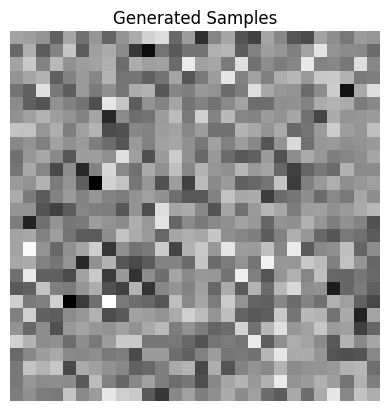

In [7]:
sample_and_plot(model, num_samples=1)

### Explain what you see.
The generated sample appears as random noise with no recognizable digit-like structure. This is expected, as the model has not been trained yet. Without training, the inverse flow has not learned to map Gaussian samples to the MNIST distribution.

### Training Loop
Let us now complete a training loop for the RealNVP Model.

In [8]:
def train(model, train_loader, num_epochs=20):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(num_epochs):
        total_loss = 0
        for x, _ in train_loader:
            x = x.to(device)

            # Compute loss and optimize
            loss = -model.log_likelihood(x).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


We now train our model.

In [9]:
model = RealNVP(input_dim, hidden_dim, num_units).to(device)
train(model, train_loader, num_epochs=20)

Epoch [1/20], Loss: -1150.6874
Epoch [2/20], Loss: -1239.8169
Epoch [3/20], Loss: -1256.7689
Epoch [4/20], Loss: -1270.5374
Epoch [5/20], Loss: -1282.0302
Epoch [6/20], Loss: -1289.7681
Epoch [7/20], Loss: -1294.3895
Epoch [8/20], Loss: -1298.0962
Epoch [9/20], Loss: -1298.9712
Epoch [10/20], Loss: -1301.5556
Epoch [11/20], Loss: -1300.8623
Epoch [12/20], Loss: -1303.4683
Epoch [13/20], Loss: -1303.0940
Epoch [14/20], Loss: -1303.5781
Epoch [15/20], Loss: -1304.7895
Epoch [16/20], Loss: -1301.9109
Epoch [17/20], Loss: -1302.3479
Epoch [18/20], Loss: -1301.2885
Epoch [19/20], Loss: -1303.5816
Epoch [20/20], Loss: -1302.6044


Let's sample the model once again.

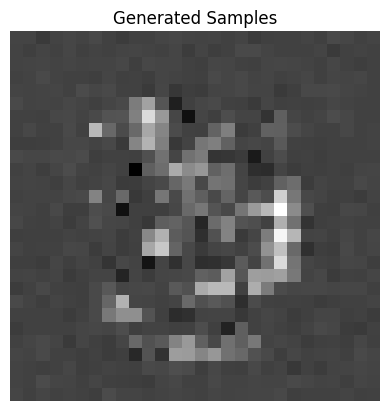

In [10]:
sample_and_plot(model, num_samples=1)

### Explain your observation.
The sample is still noise but has improved from the untrained model. A pattern of bright region (potentially as strokes) with darker borders starts to show up. Overall, the digit is not clearly recognizable, but it's clear that the model is indeed learning.  


### Propose a metric to evaluate the quality of the generated image, which can explain the higher quality of the trained model as compared to untrained one.
FID (Fréchet Inception Distance) would be a suitable metric. It measures the similarity between the distributions of generated and real images by computing the Fréchet distance between their feature representations extracted by a pretrained network. A lower FID indicates higher quality generation. An untrained model produces random noise that is far from the real MNIST distribution would result in a high FID, while a trained model generates more digit-like images that bring the two distributions closer together would result in a lower FID.